In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

Load the dataset

In [25]:
df = pd.read_csv("creditcard_2023.csv")

In [26]:
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0.0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0.0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0.0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0.0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0.0


id: Unique identifier for each transaction.
V1-V28: Anonymized features representing various transaction attributes (e.g., time, location, etc.).
Amount: The transaction amount.
Class: Binary label indicating whether the transaction is fraudulent (1) or not (0).

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38587 entries, 0 to 38586
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      38587 non-null  int64  
 1   V1      38587 non-null  float64
 2   V2      38587 non-null  float64
 3   V3      38587 non-null  float64
 4   V4      38587 non-null  float64
 5   V5      38587 non-null  float64
 6   V6      38587 non-null  float64
 7   V7      38587 non-null  float64
 8   V8      38587 non-null  float64
 9   V9      38587 non-null  float64
 10  V10     38587 non-null  float64
 11  V11     38587 non-null  float64
 12  V12     38587 non-null  float64
 13  V13     38587 non-null  float64
 14  V14     38587 non-null  float64
 15  V15     38587 non-null  float64
 16  V16     38587 non-null  float64
 17  V17     38587 non-null  float64
 18  V18     38587 non-null  float64
 19  V19     38587 non-null  float64
 20  V20     38587 non-null  float64
 21  V21     38586 non-null  float64
 22

In [28]:
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,38587.000000,38587.000000,38587.000000,38587.000000,38587.000000,38587.000000,38587.000000,38587.000000,38587.000000,38587.000000,...,38586.000000,38586.000000,38586.000000,38586.000000,38586.000000,38586.000000,38586.000000,38586.000000,38586.000000,38586.000000
mean,19293.000000,0.329214,-0.465955,1.050013,-0.642976,0.242730,0.492922,0.445529,-0.134558,0.747091,...,-0.121236,-0.123657,-0.053350,0.139499,0.155278,-0.026937,-0.204345,-0.091465,11974.093611,0.002669
std,11139.251755,0.625825,0.619331,0.700288,0.658461,0.637452,0.713223,0.536618,0.264173,0.866844,...,0.289004,0.575545,0.554678,1.105137,0.711288,1.113339,0.475447,0.730140,6929.383452,0.051598
min,0.000000,-2.637662,-25.480046,-2.518308,-4.468314,-5.182978,-18.642598,-3.038728,-6.595785,-2.170915,...,-10.699713,-6.262872,-19.297443,-4.067968,-10.230967,-4.059129,-5.536809,-24.176384,50.120000,0.000000
25%,9646.500000,-0.151668,-0.630139,0.595152,-1.004414,-0.029739,0.095670,0.248569,-0.186744,0.191389,...,-0.199850,-0.517493,-0.202367,-0.553483,-0.290175,-0.791056,-0.309006,-0.116947,5973.705000,0.000000
50%,19293.000000,0.099677,-0.409237,0.955077,-0.541133,0.155470,0.384055,0.408164,-0.141746,0.556262,...,-0.134852,-0.122482,-0.076201,0.154298,0.204328,-0.132786,-0.227996,-0.048485,11875.340000,0.000000
75%,28939.500000,0.959805,-0.204195,1.442522,-0.190550,0.376178,0.747130,0.594214,-0.080073,1.147657,...,-0.063591,0.237285,0.054520,0.845794,0.617031,0.668685,-0.138486,0.083287,17990.095000,0.000000
max,38586.000000,1.695400,3.368287,4.440555,2.576901,41.540257,9.704313,41.568286,5.958040,12.171681,...,6.834415,6.492043,23.570216,11.029578,10.424231,5.623285,26.944437,13.277404,24039.880000,1.000000


Exploratory Data Analysis (EDA)

In [29]:
df["Class"].value_counts()

,count
Class,
0.0,38483
1.0,103


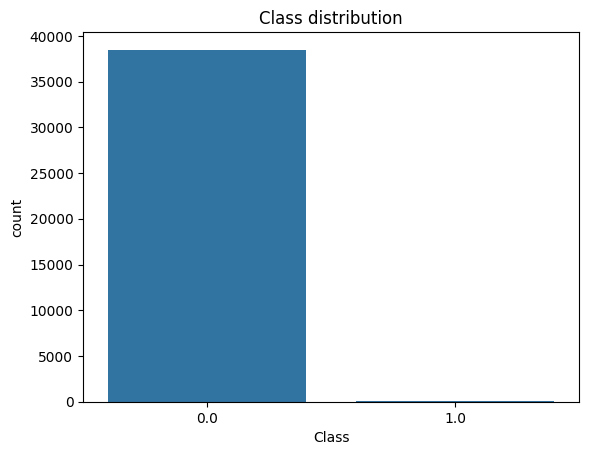

In [30]:
sns.countplot(x='Class', data=df)
plt.title("Class distribution")
plt.show()

In [31]:
# % of frauds to the total data

(df["Class"].value_counts()[1] / df.shape[0]) * 100

np.float64(0.2669292766994065)

In [32]:
# check missing values

df.isnull().sum()

,0
id,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


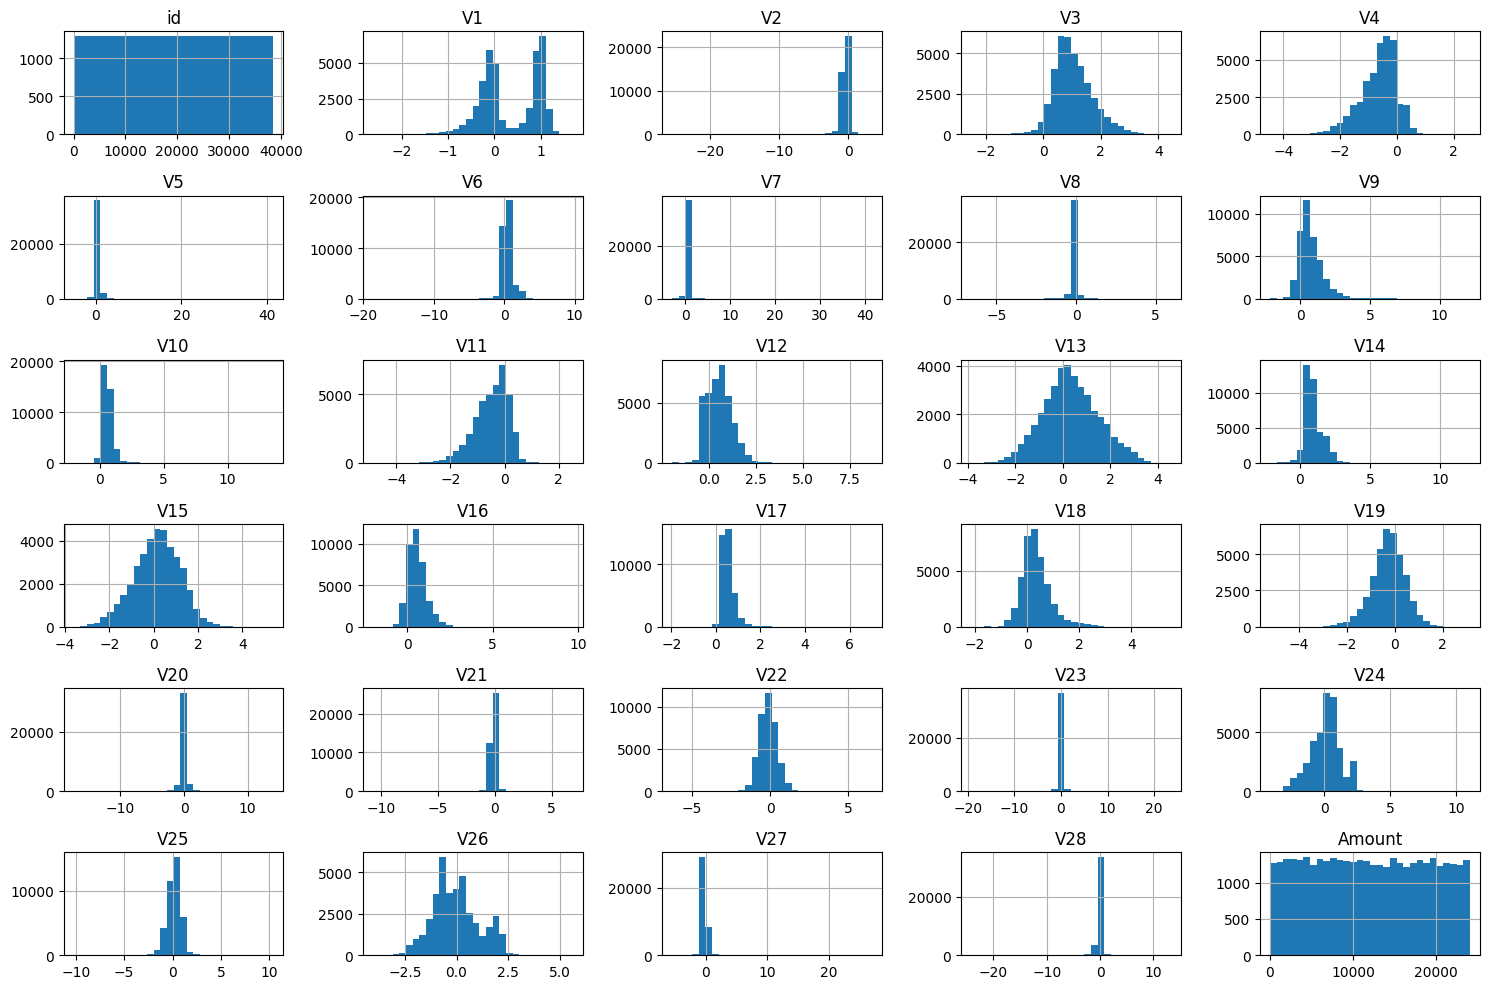

In [33]:
# Distribution of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Class')
df[numeric_cols].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()


In [34]:
df["Amount"].describe()

,Amount
count,38586.000000
mean,11974.093611
std,6929.383452
min,50.120000
25%,5973.705000
50%,11875.340000
75%,17990.095000
max,24039.880000


Text(0.5, 1.0, 'Amount Distribution (log scale)')

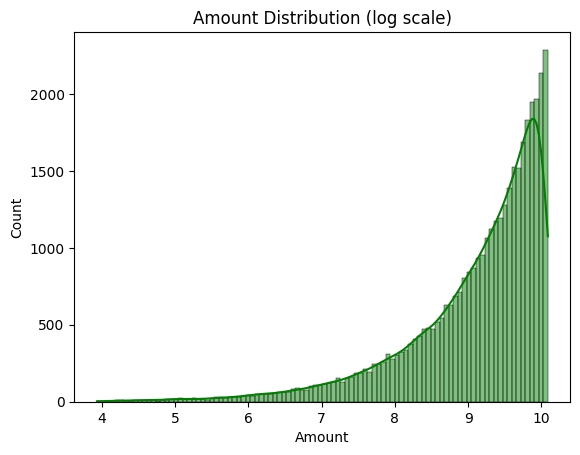

In [35]:
sns.histplot(np.log1p(df["Amount"]), bins = 100, kde = True, color= "green")
plt.title("Amount Distribution (log scale)")

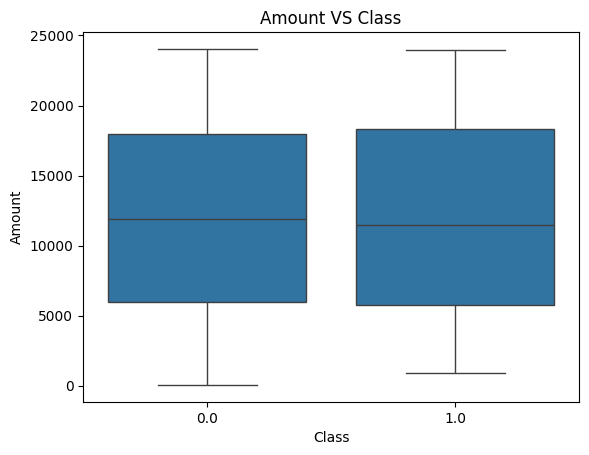

In [36]:
sns.boxplot(data= df[df["Amount"] < 25000], x = "Class", y = "Amount")
plt.title("Amount VS Class")
plt.show()

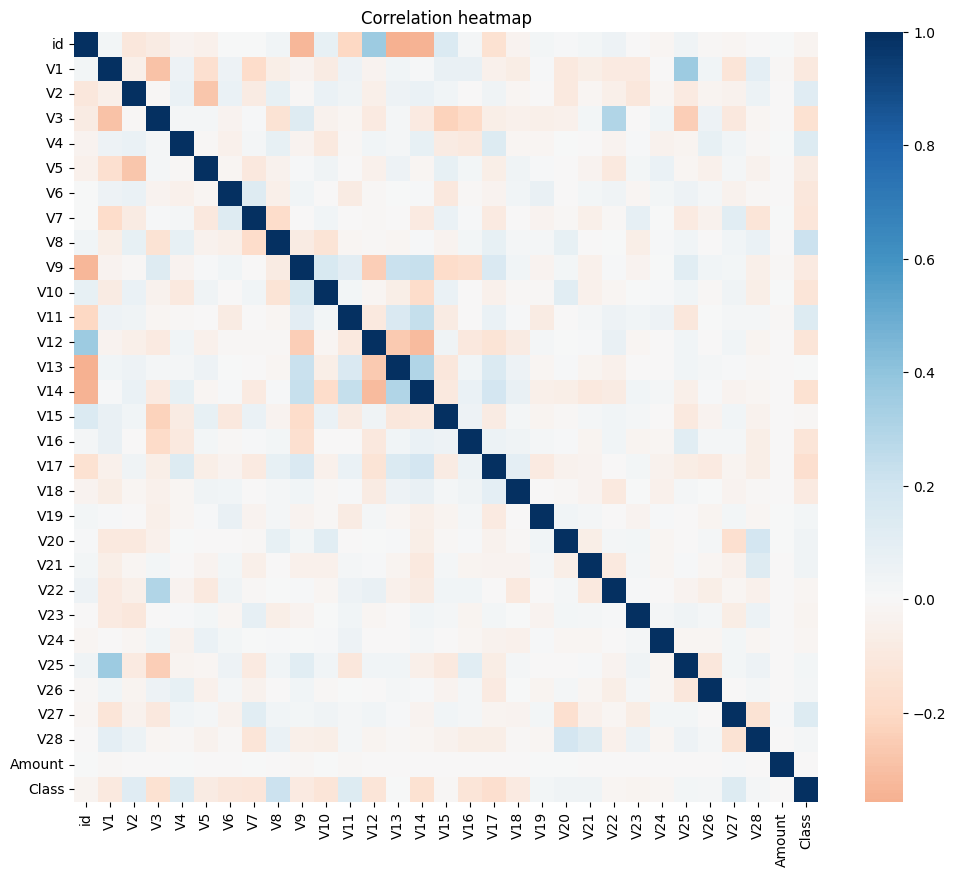

In [37]:
# Correlation heatmap

plt.figure(figsize = (12,10))
sns.heatmap(df.corr(), cmap="RdBu", center = 0)
plt.title("Correlation heatmap")
plt.show()

Data Cleaning

In [38]:
# Fill missing values with column median
df = df.fillna(df.median(numeric_only=True))

In [39]:
df.isnull().sum().sum()

np.int64(0)

In [40]:
df = df.drop(columns=['id'])

In [41]:
# check for dupicates
df.duplicated().sum()

np.int64(0)

In [42]:
df.shape

(38587, 30)

Preprocessing for modelling


In [43]:
#Split features and target

X = df.drop(columns=['Class'])
y = df['Class']

In [44]:
#Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train set:", X_train.shape, y_train.value_counts())
print("Test set:", X_test.shape, y_test.value_counts())

Train set: (30869, 29) Class
0.0    30787
1.0       82
Name: count, dtype: int64
Test set: (7718, 29) Class
0.0    7697
1.0      21
Name: count, dtype: int64


In [45]:
#Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
#Handle class imbalance

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(y_train_res.value_counts())

Class
0.0    30787
1.0    30787
Name: count, dtype: int64
